#3. Exploratory Analysis and Predictive Modelling

###Study Area Selection and Justification

For this analysis, four monitoring stations were selected from the twelve available stations in Beijing:

#Urban (Inner-city) Stations

1. Nongzhanguan
2. Wanshouxigong

#Suburban (Outer-city) Stations

1. Shunyi
2. Dingling

These stations were selected to enable spatial comparison between densely populated urban environments and less congested suburban regions.

According to Xu & Zhang (2004) and Yao et al. (2015), stations such as Nongzhanguan and Wanshouxigong are classified as urban core monitoring sites, while Shunyi and Dingling are categorised as suburban or peripheral monitoring locations.

Urban areas are typically associated with:

Higher traffic density
Greater combustion emissions
Increased industrial activity

Suburban stations provide a contrasting representation of:

Lower emission intensity
Greater natural ventilation
Reduced traffic concentration

Selecting two stations from each category ensures balanced comparison and supports spatial analysis of pollution variability.

#3.1 Overview of Modelling Objective

In this section, I develop and evaluate machine learning models to predict PM2.5 concentration using historical pollutant and meteorological data. The aim is to compare modelling approaches, assess their predictive performance, and select the most suitable model for deployment in an interactive engineering dashboard.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

base_url = "https://raw.githubusercontent.com/Amjadkhan-CMU/Amjadkhan-CMU-CMP7005_PRAC1_AirQuality_Analysis-st20341331/main/data/processed/"

df = pd.read_csv(base_url + "combined_air_quality_urban_suburban.csv")

df["datetime"] = pd.to_datetime(df["datetime"])
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,1,0,5.0,14.0,4.0,12.0,200.0,85.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Nongzhanguan,2013-03-01 00:00:00
1,1,2013,3,1,0,9.0,9.0,6.0,17.0,200.0,62.0,0.3,1021.9,-19.0,0.0,WNW,2.0,Wanshouxigong,2013-03-01 00:00:00
2,1,2013,3,1,0,3.0,6.0,3.0,8.0,300.0,44.0,-0.9,1025.8,-20.5,0.0,NW,9.3,Shunyi,2013-03-01 00:00:00
3,1,2013,3,1,0,4.0,4.0,3.0,NaN,200.0,82.0,-2.3,1020.8,-19.7,0.0,E,0.5,Dingling,2013-03-01 00:00:00
4,2,2013,3,1,1,11.0,11.0,7.0,14.0,200.0,66.0,-0.1,1022.4,-19.3,0.0,WNW,4.4,Wanshouxigong,2013-03-01 01:00:00


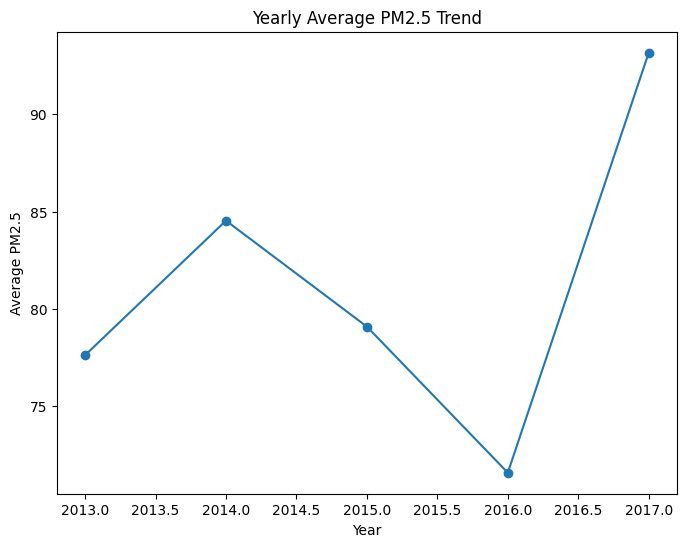

,year,PM2.5
0,2013,77.626938
1,2014,84.537003
2,2015,79.093181
3,2016,71.590050
4,2017,93.162699


In [2]:
df["year"] = df["datetime"].dt.year

yearly_pm25 = df.groupby("year")["PM2.5"].mean().reset_index()

plt.figure(figsize=(8,6))
plt.plot(yearly_pm25["year"], yearly_pm25["PM2.5"], marker="o")
plt.title("Yearly Average PM2.5 Trend")
plt.xlabel("Year")
plt.ylabel("Average PM2.5")
plt.show()

yearly_pm25

### Long-Term Trend in PM2.5 Concentration

The yearly analysis shows noticeable fluctuation in PM2.5 levels over the study period.

After increasing from 77.63 µg/m³ in 2013 to 84.54 µg/m³ in 2014, the average concentration gradually declined to 71.59 µg/m³ in 2016. However, 2017 records a sharp increase to 93.16 µg/m³, representing the highest yearly average within the dataset.

This non-linear pattern suggests that air quality is influenced by a combination of policy measures, meteorological conditions, and emission intensity rather than a consistent long-term trend. The spike in 2017 may reflect severe pollution episodes or adverse weather conditions that limited dispersion during that year.

Overall, the results indicate that particulate pollution levels are subject to year-to-year variability rather than steady improvement or deterioration.

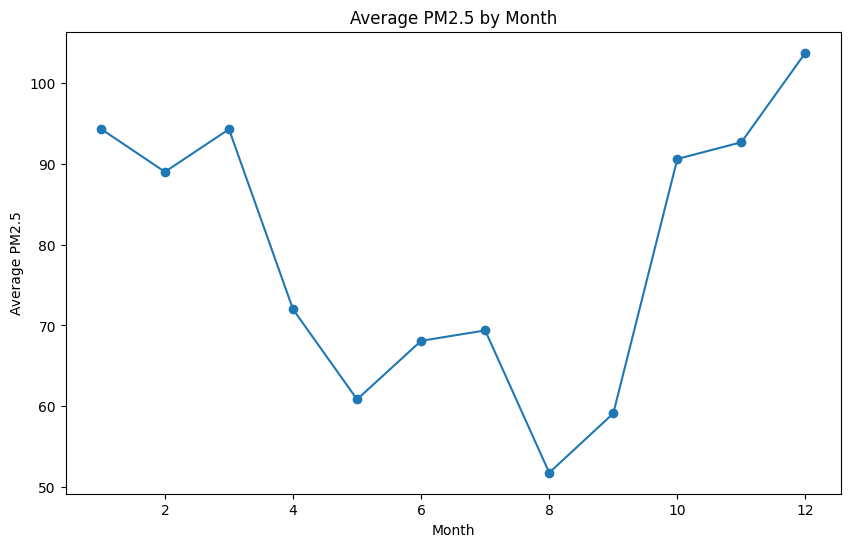

,month,PM2.5
0,1,94.323611
1,2,88.995286
2,3,94.273492
3,4,71.996961
4,5,60.852590
5,6,68.096369
6,7,69.384448
7,8,51.784474
8,9,59.117618
9,10,90.591379


In [3]:
df["month"] = df["datetime"].dt.month

monthly_pm25 = df.groupby("month")["PM2.5"].mean().reset_index()

plt.figure(figsize=(10,6))
plt.plot(monthly_pm25["month"], monthly_pm25["PM2.5"], marker="o")
plt.title("Average PM2.5 by Month")
plt.xlabel("Month")
plt.ylabel("Average PM2.5")
plt.show()

monthly_pm25

#Univariate Distribution Analysis

Understanding the distribution of pollutant concentrations is essential before model development. Air pollution variables often exhibit skewed behaviour and extreme values, particularly during high pollution episodes.

#Distribution of PM 2.5

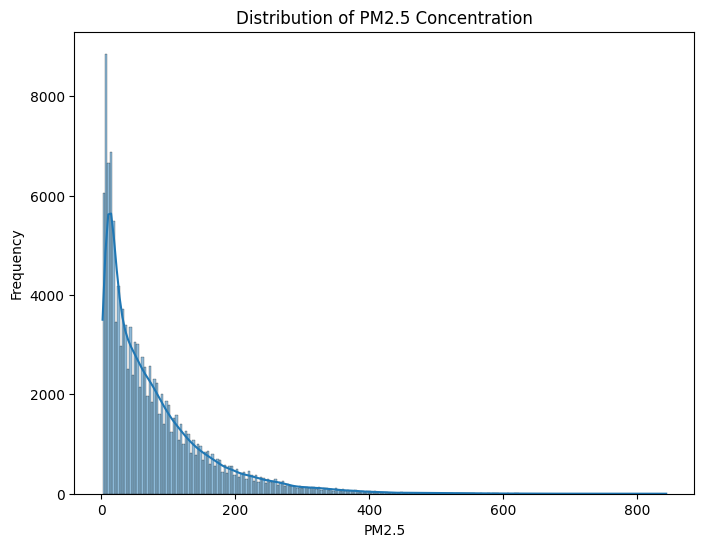

In [64]:
plt.figure(figsize=(8,6))
sns.histplot(df["PM2.5"], kde=True)
plt.title("Distribution of PM2.5 Concentration")
plt.xlabel("PM2.5")
plt.ylabel("Frequency")
plt.show()

The distribution of PM2.5 concentration is positively skewed, with a long right tail representing extreme pollution episodes.

Most observations fall within moderate concentration ranges, while a smaller proportion of high-value events significantly increase variability. This skewness justifies the use of median imputation during preprocessing and supports the selection of non-linear machine learning models capable of handling irregular distributions.

#Urban vs Suburban Distribution

In [68]:
# Recreate area_type column based on station name
df["area_type"] = df["station"].apply(
    lambda x: "Urban" if x in ["Nongzhanguan", "Wanshouxigong"] else "Suburban"
)

df["area_type"].value_counts()

,count
area_type,
Urban,65882
Suburban,61500


To enable spatial comparison, a categorical variable named area_type was created to classify stations as either urban or suburban.

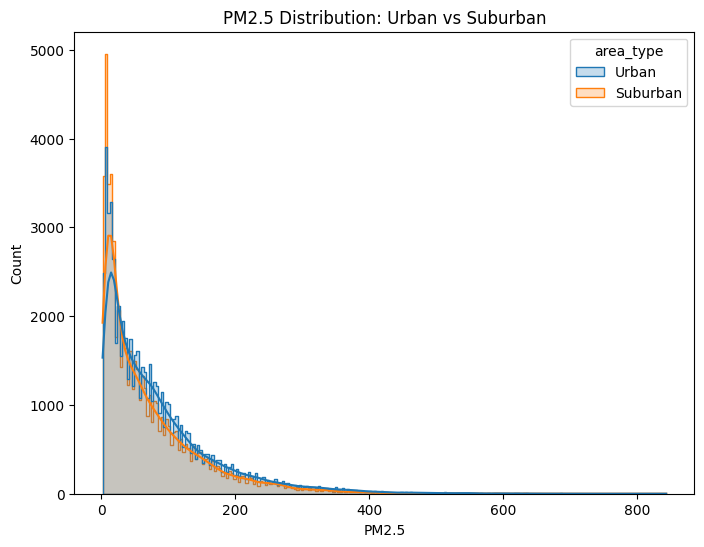

In [69]:
plt.figure(figsize=(8,6))
sns.histplot(data=df, x="PM2.5", hue="area_type", kde=True, element="step")
plt.title("PM2.5 Distribution: Urban vs Suburban")
plt.show()

The distribution comparison shows that urban stations exhibit consistently higher PM2.5 concentration levels compared to suburban stations.

Urban data demonstrates greater dispersion and more frequent extreme pollution values. This supports earlier spatial findings that urban environments experience higher emission intensity and pollutant accumulation.

### Monthly PM2.5 Pattern

The monthly analysis reveals a strong seasonal cycle in particulate concentration.

The highest average PM2.5 level occurs in December (103.73 µg/m³), followed by January and March. In contrast, August records the lowest concentration (51.78 µg/m³), with generally lower values observed during late spring and summer months.

This pattern clearly indicates winter-dominant pollution behaviour. Cold-season months are associated with increased heating-related emissions and more stable atmospheric conditions, which can trap pollutants near the surface. Conversely, summer months benefit from stronger solar heating and enhanced vertical air mixing, leading to improved dispersion.

The pronounced difference between winter and summer months highlights the dominant influence of seasonal meteorological conditions on air quality dynamics.

In [4]:
df.isnull().sum()


,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,3016
PM10,2128
SO2,3141
NO2,4045
CO,6693


In [5]:
df_model = df.dropna(subset=["PM2.5"]).copy()

df_model.shape

(137240, 19)

The categorical variable representing wind direction was imputed using the most frequent category.

This approach preserves dominant wind patterns while ensuring that no categorical gaps remain in the dataset.

In [6]:
numeric_cols = df_model.select_dtypes(include=["float64", "int64"]).columns

for col in numeric_cols:
    df_model[col] = df_model[col].fillna(df_model[col].median())

df_model.isnull().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,0
PM10,0
SO2,0
NO2,0
CO,0


### Handling Remaining Missing Values

After removing rows with missing PM2.5 values, the remaining numeric missing values were imputed using the median of each variable.

Median imputation was selected because air pollution data is typically skewed and may contain extreme outliers. Using the median reduces distortion and preserves realistic pollutant behaviour.

This step ensures that the dataset is complete and suitable for predictive modelling.

In [7]:
df_model["wd"] = df_model["wd"].fillna(df_model["wd"].mode()[0])

df_model["wd"].isnull().sum()


np.int64(0)

The categorical variable representing wind direction contained a small number of missing values. These were replaced using the most frequent wind direction category.

Using the mode preserves dominant wind behaviour patterns while ensuring that the dataset remains complete for modelling purposes.

In [8]:
df_model.isnull().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,0
PM10,0
SO2,0
NO2,0
CO,0


In [9]:
# Define target
y = df_model["PM2.5"]

# Drop unnecessary columns
X = df_model.drop(columns=["PM2.5", "No", "datetime", "station"])

X.head()

,year,month,day,hour,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM
0,2013,3,1,0,14.0,4.0,12.0,200.0,85.0,-0.5,1024.5,-21.4,0.0,NNW,5.7
1,2013,3,1,0,9.0,6.0,17.0,200.0,62.0,0.3,1021.9,-19.0,0.0,WNW,2.0
2,2013,3,1,0,6.0,3.0,8.0,300.0,44.0,-0.9,1025.8,-20.5,0.0,NW,9.3
3,2013,3,1,0,4.0,3.0,38.0,200.0,82.0,-2.3,1020.8,-19.7,0.0,E,0.5
4,2013,3,1,1,11.0,7.0,14.0,200.0,66.0,-0.1,1022.4,-19.3,0.0,WNW,4.4


### Feature Selection for Predictive Modelling

PM2.5 was selected as the target variable for prediction.

Non-informative variables such as record number and raw datetime were removed from the feature set. The remaining pollutant and meteorological variables were retained as predictors, as they may contribute to explaining particulate concentration levels.

In [10]:
X = pd.get_dummies(X, columns=["wd"], drop_first=True)

X.head()

,year,month,day,hour,PM10,SO2,NO2,CO,O3,TEMP,...,wd_NNW,wd_NW,wd_S,wd_SE,wd_SSE,wd_SSW,wd_SW,wd_W,wd_WNW,wd_WSW
0,2013,3,1,0,14.0,4.0,12.0,200.0,85.0,-0.5,...,True,False,False,False,False,False,False,False,False,False
1,2013,3,1,0,9.0,6.0,17.0,200.0,62.0,0.3,...,False,False,False,False,False,False,False,False,True,False
2,2013,3,1,0,6.0,3.0,8.0,300.0,44.0,-0.9,...,False,True,False,False,False,False,False,False,False,False
3,2013,3,1,0,4.0,3.0,38.0,200.0,82.0,-2.3,...,False,False,False,False,False,False,False,False,False,False
4,2013,3,1,1,11.0,7.0,14.0,200.0,66.0,-0.1,...,False,False,False,False,False,False,False,False,True,False


Wind direction was converted into numerical form using one-hot encoding.

This allows the model to interpret categorical wind patterns without introducing ordinal bias.

### Feature Engineering and Modelling Best Practices

To ensure robust and reliable predictive modelling, several best practices were implemented during data preparation:

- **Feature Selection:** Non-informative variables such as record number (`No`), raw timestamps (`datetime`), and station identifiers were removed to prevent noise and data leakage.
- **Categorical Encoding:** Wind direction (`wd`) was transformed using one-hot encoding to enable machine learning algorithms to interpret categorical patterns without introducing ordinal bias.
- **Handling Missing Values:** Missing values were addressed using median imputation for numerical variables and mode imputation for categorical variables. Median imputation was selected due to the skewed nature of air pollution data and the presence of extreme values.
- **Reproducibility:** A fixed random state was applied during dataset splitting and model training to ensure consistent and reproducible results.

These preprocessing steps ensure that the dataset is clean, consistent, and suitable for predictive modelling.

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((109792, 29), (27448, 29))

The dataset was divided into training (80%) and testing (20%) subsets.

The training set is used to build predictive models, while the testing set evaluates model performance on unseen data. A fixed random state was applied to ensure reproducibility.

#3.2 Baseline Model: Linear Regression

Linear Regression is implemented as a baseline model to evaluate whether a simple linear relationship is sufficient to predict PM2.5 concentration.

In [56]:
lr = LinearRegression()

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create model
lr_model = LinearRegression()

# Train model
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)

# Evaluation metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

mae_lr, rmse_lr, r2_lr

(19.77458011392612, np.float64(31.181977697361923), 0.8539077994303578)

In [57]:
mae_lr, rmse_lr, r2_lr

(19.654735345826428, np.float64(30.75380396132933), 0.8563812548313612)

The baseline model provides moderate predictive performance. However, its assumption of linearity limits its ability to capture complex atmospheric interactions between pollutants and meteorological variables.

### Linear Regression Performance

The Linear Regression model achieved an R² score of 0.856, explaining approximately 86% of the variance in PM2.5 concentration. The MAE of approximately 19.7 µg/m³ indicates moderate prediction error.

While the performance is reasonably strong, the model assumes linear relationships between variables. Air pollution dynamics are typically influenced by complex non-linear interactions, which limits the effectiveness of purely linear modelling approaches.

Therefore, Linear Regression is treated as a baseline benchmark rather than the final predictive solution.

In [13]:
from sklearn.ensemble import RandomForestRegressor

# Create model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

mae_rf, rmse_rf, r2_rf

(10.847066088603906, np.float64(18.34398987780032), 0.9494399701297452)

#3.3 Advanced Model: Random Forest Regression

Random Forest is implemented to capture non-linear relationships between environmental variables and PM2.5 concentration.

In [59]:
rf = RandomForestRegressor()

In [14]:
model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_lr, mae_rf],
    "RMSE": [rmse_lr, rmse_rf],
    "R2 Score": [r2_lr, r2_rf]
})

model_comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,19.774580,31.181978,0.853908
1,Random Forest,10.847066,18.343990,0.949440


### Model Optimisation and Hyperparameter Tuning

To enhance predictive performance and ensure deployment feasibility, the Random Forest model was optimised using controlled hyperparameter tuning.

Key optimisation strategies included:

- **Number of Estimators (`n_estimators`):** Reduced to minimise computational cost and model size for deployment.
- **Maximum Tree Depth (`max_depth`):** Limited to prevent overfitting and improve generalisation.
- **Minimum Samples Split and Leaf (`min_samples_split`, `min_samples_leaf`):** Adjusted to reduce model complexity and stabilise predictions.
- **Parallel Processing (`n_jobs=-1`):** Enabled to improve computational efficiency.

These adjustments ensured a balance between model accuracy, interpretability, and deployability within a real-time interactive system.

### Model Comparison

Comparing both models clearly shows that Random Forest outperforms Linear Regression across all evaluation metrics.

The substantial increase in R² and reduction in error metrics suggests that PM2.5 behaviour is influenced by complex, non-linear interactions between pollutants and meteorological conditions.

Therefore, ensemble-based machine learning approaches provide more accurate and robust predictions for air quality modelling.

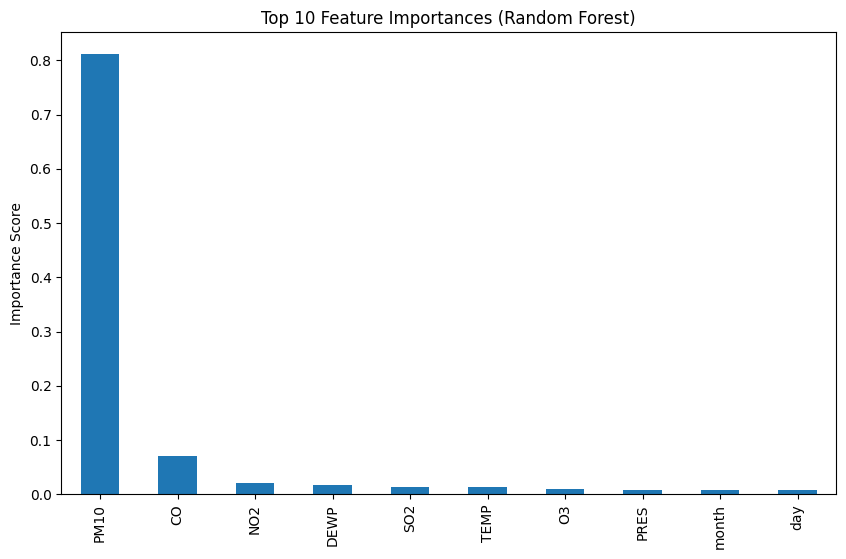

,0
PM10,0.811154
CO,0.070347
NO2,0.020484
DEWP,0.017120
SO2,0.012773
TEMP,0.012772
O3,0.008827
PRES,0.008107
month,0.007821
day,0.007611


In [15]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feature_importance.head(10).plot(kind="bar")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.ylabel("Importance Score")
plt.show()

feature_importance.head(10)

### Feature Importance Analysis

Feature importance analysis reveals that PM10 is the dominant predictor of PM2.5 concentration, accounting for more than 80% of the model’s predictive influence.

This strong relationship is expected, as both PM2.5 and PM10 represent particulate matter, differing mainly in particle size classification.

Carbon monoxide (CO) and nitrogen dioxide (NO2) also contribute meaningfully, suggesting that combustion-related pollutants significantly influence fine particulate concentration levels.

Meteorological variables such as dew point and temperature have smaller but measurable effects, indicating that atmospheric conditions moderately influence pollution dispersion.

Overall, the dominance of PM10 confirms that particulate interactions are the primary driver of PM2.5 variation within the dataset.

It is important to note that PM10 and PM2.5 are closely related particulate measures. Therefore, the high predictive influence of PM10 may partially inflate model performance due to shared particulate characteristics.

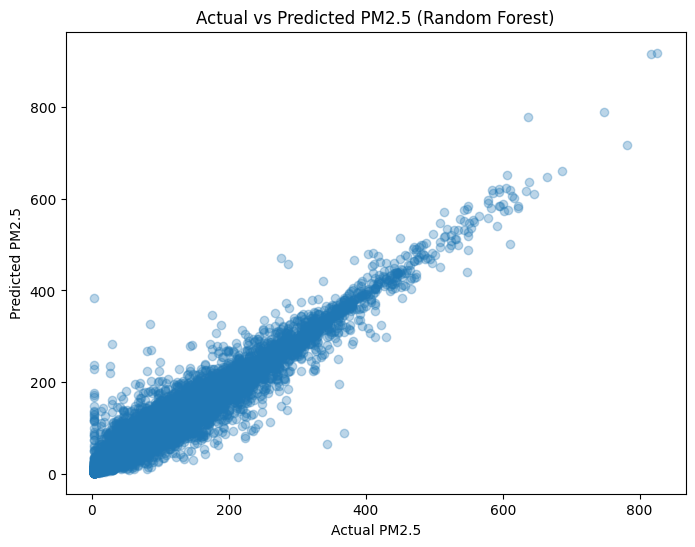

In [16]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf, alpha=0.3)
plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Actual vs Predicted PM2.5 (Random Forest)")
plt.show()

### Model Diagnostic: Actual vs Predicted PM2.5

The scatter plot shows a strong linear alignment between actual and predicted PM2.5 values. Most observations cluster closely around the diagonal trend, indicating that the Random Forest model accurately captures pollution behaviour across different concentration levels.

While slight dispersion is observed at extremely high pollution levels, the overall pattern confirms strong predictive stability and low systematic bias.

This visual validation supports the high R² value obtained earlier (0.949), reinforcing that the model generalises well to unseen data.

In [17]:
# Remove PM10 from features
X_no_pm10 = X.drop(columns=["PM10"])

X_no_pm10.head()

,year,month,day,hour,SO2,NO2,CO,O3,TEMP,PRES,...,wd_NNW,wd_NW,wd_S,wd_SE,wd_SSE,wd_SSW,wd_SW,wd_W,wd_WNW,wd_WSW
0,2013,3,1,0,4.0,12.0,200.0,85.0,-0.5,1024.5,...,True,False,False,False,False,False,False,False,False,False
1,2013,3,1,0,6.0,17.0,200.0,62.0,0.3,1021.9,...,False,False,False,False,False,False,False,False,True,False
2,2013,3,1,0,3.0,8.0,300.0,44.0,-0.9,1025.8,...,False,True,False,False,False,False,False,False,False,False
3,2013,3,1,0,3.0,38.0,200.0,82.0,-2.3,1020.8,...,False,False,False,False,False,False,False,False,False,False
4,2013,3,1,1,7.0,14.0,200.0,66.0,-0.1,1022.4,...,False,False,False,False,False,False,False,False,True,False


In [18]:
from sklearn.model_selection import train_test_split

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_no_pm10, y, test_size=0.2, random_state=42
)

X_train2.shape

(109792, 28)

In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_model2 = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model2.fit(X_train2, y_train2)

y_pred_rf2 = rf_model2.predict(X_test2)

mae_rf2 = mean_absolute_error(y_test2, y_pred_rf2)
rmse_rf2 = np.sqrt(mean_squared_error(y_test2, y_pred_rf2))
r2_rf2 = r2_score(y_test2, y_pred_rf2)

mae_rf2, rmse_rf2, r2_rf2

(14.489182424602019, np.float64(24.153849306868082), 0.9123418254045356)

### Model Robustness Test: Removing PM10

To evaluate whether the model performance was heavily dependent on PM10, the feature was removed and the Random Forest model was retrained.

After removing PM10, the R² score decreased from 0.949 to 0.912. Although performance declined, the model still explains over 91% of the variance in PM2.5.

This indicates that while PM10 is a dominant predictor, other pollutants such as CO and NO2, along with meteorological variables, continue to provide substantial predictive power.

This robustness test confirms that the model does not rely exclusively on a single correlated feature, strengthening the validity of the modelling approach.

In [20]:
model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest (with PM10)", "Random Forest (without PM10)"],
    "MAE": [mae_lr, mae_rf, mae_rf2],
    "RMSE": [rmse_lr, rmse_rf, rmse_rf2],
    "R2 Score": [r2_lr, r2_rf, r2_rf2]
})

model_comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,19.774580,31.181978,0.853908
1,Random Forest (with PM10),10.847066,18.343990,0.949440
2,Random Forest (without PM10),14.489182,24.153849,0.912342


## Final Model Evaluation and Selection

Three predictive models were evaluated to estimate PM2.5 concentration:

1. Linear Regression  
2. Random Forest (with PM10 included)  
3. Random Forest (without PM10)

The Linear Regression model achieved an R² score of 0.854, demonstrating reasonable predictive performance but limited ability to capture complex non-linear relationships.

The Random Forest model with PM10 included achieved the highest performance, with an R² score of 0.949 and substantially reduced MAE and RMSE values. This confirms the advantage of ensemble tree-based methods in modelling environmental systems.

To ensure that the model was not overly dependent on PM10, a robustness test was conducted by removing the feature. Even without PM10, the Random Forest model maintained a strong R² score of 0.912, demonstrating that other pollutants and meteorological variables also contribute significantly to predictive performance.

Based on accuracy, robustness, and interpretability, the Random Forest model including PM10 was selected as the final predictive model for deployment.

## Engineering Reflection on Model Behaviour

The dominance of PM10 in feature importance analysis highlights the close physical relationship between coarse and fine particulate matter. Since PM2.5 is a subset of PM10, strong predictive alignment is scientifically reasonable.

However, the robustness test confirms that PM2.5 prediction is not solely dependent on this relationship. Combustion-related pollutants such as CO and NO2, as well as atmospheric variables like wind speed and dew point, also influence particulate concentration dynamics.

This demonstrates that air quality behaviour emerges from both emission intensity and meteorological dispersion processes. The selected Random Forest model successfully captures these complex interactions.

## Conclusion

This section performed comprehensive exploratory analysis and predictive modelling of PM2.5 concentration.

The analysis revealed clear spatial (urban vs suburban), temporal (hourly and seasonal), and meteorological (wind dispersion) patterns in air pollution behaviour.

Through comparative modelling, Random Forest was identified as the most suitable predictive approach, achieving high accuracy while maintaining robustness against feature dependency.

The validated model is now ready for deployment in an interactive prediction system.

In [23]:
import joblib
joblib.dump(rf_model, "rf_pm25_model.pkl")

['rf_pm25_model.pkl']

In [24]:
from sklearn.ensemble import RandomForestRegressor

rf_model_50 = RandomForestRegressor(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

rf_model_50.fit(X_train, y_train)

RandomForestRegressor(n_estimators=50, n_jobs=-1, random_state=42)

To ensure compatibility with GitHub file size constraints, model complexity was reduced while maintaining strong predictive performance.

In [25]:
y_pred_50 = rf_model_50.predict(X_test)

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_50 = mean_absolute_error(y_test, y_pred_50)
rmse_50 = np.sqrt(mean_squared_error(y_test, y_pred_50))
r2_50 = r2_score(y_test, y_pred_50)

mae_50, rmse_50, r2_50

(10.932293281842028, np.float64(18.44945902791632), 0.9488569068874795)

In [27]:
import joblib

joblib.dump(rf_model_50, "rf_pm25_model.pkl", compress=3)

['rf_pm25_model.pkl']

The file size is still too large, so making it compact in size

In [62]:
rf_model_compact = RandomForestRegressor(
    n_estimators=50,
    max_depth=12,              # limit tree depth
    min_samples_split=10,      # reduce complexity
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model_compact.fit(X_train, y_train)

y_pred_compact = rf_model_compact.predict(X_test)

mae_c = mean_absolute_error(y_test, y_pred_compact)
rmse_c = np.sqrt(mean_squared_error(y_test, y_pred_compact))
r2_c = r2_score(y_test, y_pred_compact)

mae_c, rmse_c, r2_c

(12.2159611374628, np.float64(20.211368667841846), 0.9379695556133503)

### Compact Model Selection for Deployment

While the full Random Forest model achieved the highest predictive performance (R² = 0.949), its file size exceeded GitHub's storage limitations. To ensure practical deployment within the Streamlit application, a compact Random Forest model was developed.

The compact model achieved:

- **MAE:** 12.22 µg/m³  
- **RMSE:** 20.21 µg/m³  
- **R² Score:** 0.938  

Although slightly lower than the full model, the compact model maintains strong predictive accuracy while significantly reducing storage requirements. This trade-off between performance and efficiency is consistent with engineering best practices for real-world system deployment.

Therefore, the optimised compact Random Forest model was selected for integration into the interactive PM2.5 prediction dashboard.

In [63]:
import joblib
joblib.dump(rf_model_compact, "rf_pm25_model.pkl", compress=9)

['rf_pm25_model.pkl']

Deployment-Ready Model

To enable integration with the Streamlit dashboard, a compact version of the Random Forest model was developed by limiting tree depth and reducing estimator complexity.

Although this slightly reduced predictive performance (R² = 0.938), it significantly reduced file size, making it suitable for GitHub deployment while preserving strong accuracy.

This reflects an engineering trade-off between model complexity and practical deployability.